# Trabajo Práctico 1 - Visión por Computadora I

Resolución basada en los ejemplos de `Codigo/Clase1` y `Codigo/Clase2`.

In [1]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

BASE = Path('Material_TPs/TP1')
if not BASE.exists():
    BASE = Path('.')

## Parte 1 - White Patch

White Patch supone que el píxel de mayor respuesta de cada canal corresponde a una superficie blanca. Por eso escala cada canal para que su máximo llegue a 255.

In [2]:
def white_patch(img):
    maximos = img.max(axis=(0, 1))
    ganancias = 255 / np.maximum(maximos, 1)
    return np.round(np.clip(img.astype(np.float32) * ganancias, 0, 255)).astype(np.uint8)

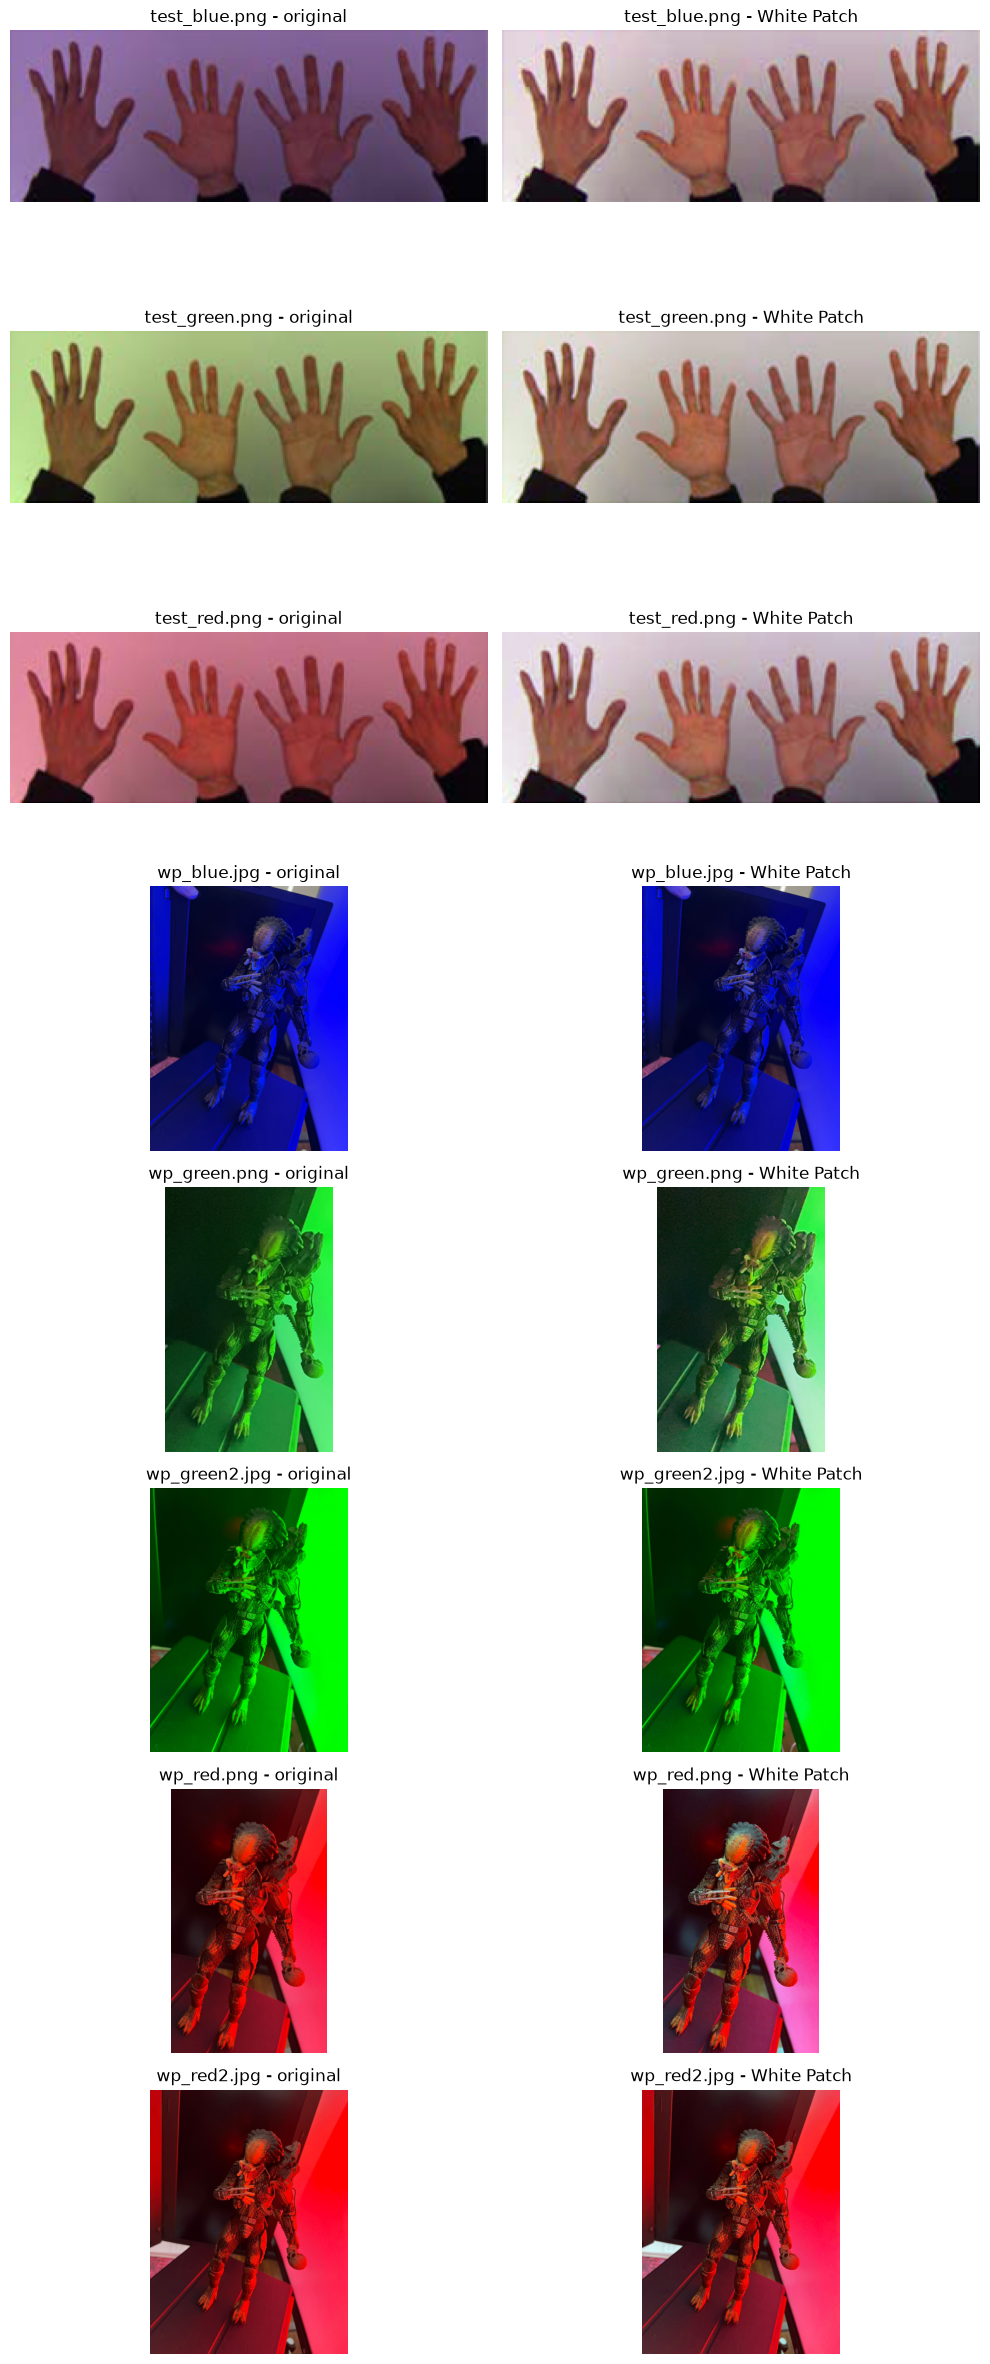

In [3]:
archivos = sorted((BASE / 'white_patch').glob('*'))
fig, axes = plt.subplots(len(archivos), 2, figsize=(10, 3 * len(archivos)))

for fila, archivo in enumerate(archivos):
    original = cv.imread(str(archivo))
    corregida = white_patch(original)

    axes[fila, 0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    axes[fila, 0].set_title(f'{archivo.name} - original')
    axes[fila, 1].imshow(cv.cvtColor(corregida, cv.COLOR_BGR2RGB))
    axes[fila, 1].set_title(f'{archivo.name} - White Patch')
    axes[fila, 0].axis('off')
    axes[fila, 1].axis('off')

plt.tight_layout()
plt.show()

### Análisis

El método reduce satisfactoriamente las dominantes roja y verde cuando la escena contiene una referencia suficientemente clara. En `wp_blue.jpg`, en cambio, los tres canales ya poseen algún píxel con valor 255: las ganancias resultan iguales a 1 y la fuerte dominante azul queda sin corregir.

Esta es la principal limitación de White Patch: el máximo de cada canal no necesariamente pertenece al mismo objeto blanco ni representa el color del iluminante. Un reflejo, un píxel saturado, ruido o un objeto de color intenso pueden fijar ese máximo. Además, si un canal quedó recortado o casi no recibió señal, la información perdida no puede recuperarse. Tampoco modela escenas con más de una iluminación.

## Parte 2 - Histogramas

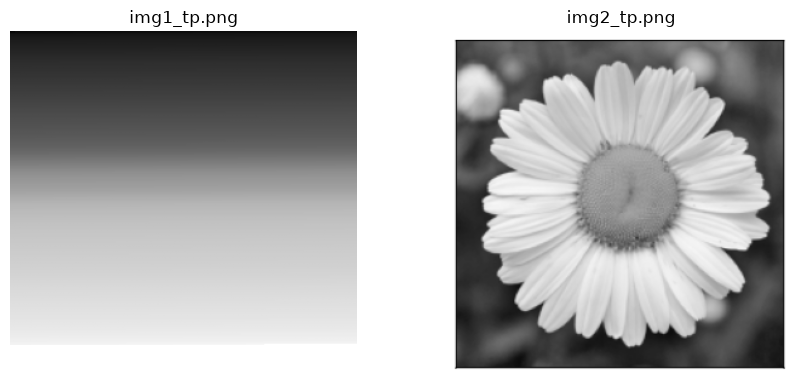

In [4]:
img1 = cv.imread(str(BASE / 'img1_tp.png'), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(str(BASE / 'img2_tp.png'), cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp.png')
axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp.png')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

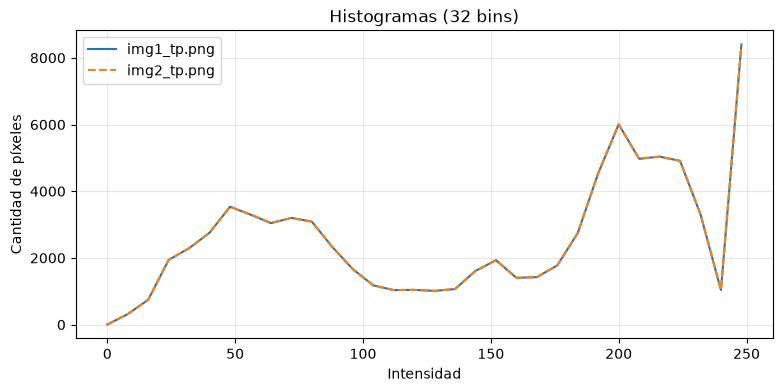

¿Los histogramas son iguales? True


In [5]:
bins = 32
hist1, bordes = np.histogram(img1.ravel(), bins=bins, range=(0, 256))
hist2, _ = np.histogram(img2.ravel(), bins=bins, range=(0, 256))

plt.figure(figsize=(9, 4))
plt.plot(bordes[:-1], hist1, label='img1_tp.png')
plt.plot(bordes[:-1], hist2, '--', label='img2_tp.png')
plt.xlabel('Intensidad')
plt.ylabel('Cantidad de píxeles')
plt.title(f'Histogramas ({bins} bins)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('¿Los histogramas son iguales?', np.array_equal(hist1, hist2))

### Análisis

Se eligieron 32 bins: agrupan niveles vecinos y permiten ver claramente la forma global sin el ruido visual de 256 barras. Las dos imágenes son completamente distintas, pero sus histogramas coinciden: tienen la misma cantidad de píxeles para cada rango de intensidad y sólo cambia su posición espacial.

Por lo tanto, un histograma puede servir como *feature* global para describir brillo, contraste o distribución de color, y puede ser útil si esas propiedades distinguen las clases. Sin embargo, por sí solo no es suficiente para clasificación o detección: descarta forma, textura y ubicación. Este par es un contraejemplo directo, porque un modelo basado únicamente en estos histogramas no podría separar ambas imágenes. Para detección, además, se necesita información espacial; podrían usarse histogramas por regiones como complemento, pero no reemplazan descriptores que preserven la estructura.